# Feature Extraction Debug Notebook

This notebook is used to validate `features.py` independently from the main notebook.

Run it cell by cell to check:

1. whether the input files are loaded correctly;
2. whether optional foot-landmark correction is applied;
3. whether segmentation returns valid phase boundaries;
4. whether feature extraction returns valid scalar features;
5. whether frame-level signals match the video and skeleton overlay.

In [1]:
# ============================================================
# Cell 1 — Imports and project setup
# ============================================================

from pathlib import Path
import sys
import importlib

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook is expected to be inside:
# Final repositry/notebooks/
PROJECT_ROOT = Path.cwd().parent.resolve()

# Force Python to import modules from the project root
if str(PROJECT_ROOT) in sys.path:
    sys.path.remove(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT))

# Clear previous imports when rerunning after editing .py files
for module_name in [
    "helper",
    "segmentation",
    "features",
    "features_registry",
    "feature_registry",
]:
    if module_name in sys.modules:
        del sys.modules[module_name]

# Your features.py currently imports from features_registry.py.
# This fallback also supports the singular name feature_registry.py.
try:
    import features_registry as registry_module
except ModuleNotFoundError:
    import feature_registry as registry_module
    sys.modules["features_registry"] = registry_module

from helper import (
    POINTS,
    get_xyv,
    read_fps_from_video,
)
from segmentation import (
    resolve_gait_segments,
    create_phase_dataframe,
)
from features import (
    extract_segment_features,
    compute_total_features,
)
from features_registry import (
    FEATURE_REGISTRY,
    feature_registry_dataframe,
    feature_values_dataframe,
)

import helper
import segmentation
import features

print("PROJECT_ROOT:", PROJECT_ROOT)
print("helper.py:", helper.__file__)
print("segmentation.py:", segmentation.__file__)
print("features.py:", features.__file__)
print("registry module:", registry_module.__file__)

PROJECT_ROOT: D:\Internship work\Livrables\Reconstruction\MLKit\Final repositry
helper.py: D:\Internship work\Livrables\Reconstruction\MLKit\Final repositry\helper.py
segmentation.py: D:\Internship work\Livrables\Reconstruction\MLKit\Final repositry\segmentation.py
features.py: D:\Internship work\Livrables\Reconstruction\MLKit\Final repositry\features.py
registry module: D:\Internship work\Livrables\Reconstruction\MLKit\Final repositry\features_registry.py


In [ ]:
# ============================================================
# Cell 2 — User settings
# ============================================================

CSV_PATH = PROJECT_ROOT / "examples" / "demo_skeleton_2d_pixels.csv"
VIDEO_PATH = PROJECT_ROOT / "examples" / "demo_video_blurred.mp4"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "feature_debug"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Distances used for speed and step-length calculations.
# Adjust these according to your acquisition protocol.
LATERAL_DISTANCE_M = 3.0
FRONTAL_DISTANCE_M = 3.0

# Optional preprocessing.
# This applies the helper.py correction for sudden foot-landmark jumps.
DO_CORRECT_FOOT_MISDETECTIONS = True
FOOT_JUMP_THRESHOLD_PX = 40
FOOT_CORRECTION_FRAMES_BEFORE = 2
FOOT_CORRECTION_FRAMES_AFTER = 2

# Manual segmentation overrides.
# Keep None unless automatic segmentation is visibly wrong.
MANUAL_LATERAL_START_FRAME = None
MANUAL_TURN_START_FRAME = None
MANUAL_TURN_END_FRAME = None
MANUAL_FRONTAL_END_FRAME = None

RUN_SIT_TO_STAND = True
MANUAL_STS_START_FRAME = None
MANUAL_STS_END_FRAME = None

print("CSV_PATH:", CSV_PATH)
print("VIDEO_PATH:", VIDEO_PATH)
print("CSV exists:", CSV_PATH.exists())
print("Video exists:", VIDEO_PATH.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)

CSV_PATH: D:\Internship work\Livrables\Reconstruction\MLKit\Final repositry\data\SAFE_GAIT_3D_20260708_170453_2D_Pixels.csv
VIDEO_PATH: D:\Internship work\Livrables\Reconstruction\MLKit\Final repositry\data\SAFE_GAIT_3D_20260708_170453.mp4
CSV exists: True
Video exists: True
OUTPUT_DIR: D:\Internship work\Livrables\Reconstruction\MLKit\Final repositry\outputs\feature_debug


In [3]:
# ============================================================
# Cell 3 — Load CSV and read FPS
# ============================================================

df = pd.read_csv(CSV_PATH)

if "Frame" not in df.columns and "Frame_Number" in df.columns:
    df = df.rename(columns={"Frame_Number": "Frame"})

if "Frame" not in df.columns:
    raise ValueError("The CSV must contain a column named 'Frame'.")

df = df.sort_values("Frame").reset_index(drop=True)

try:
    FPS, video_frame_count = read_fps_from_video(str(VIDEO_PATH))
except Exception as e:
    print("Could not read FPS from video.")
    print("Reason:", e)
    print("Using FPS = 30.")
    FPS = 30
    video_frame_count = None

print("CSV shape:", df.shape)
print("First frame:", int(df["Frame"].min()))
print("Last frame:", int(df["Frame"].max()))
print("FPS:", FPS)
print("Video frame count:", video_frame_count)

display(df.head())

CSV shape: (307, 100)
First frame: 0
Last frame: 348
FPS: 29.991482418993005
Video frame count: 349


,Frame,Nose_x,Nose_y,Nose_vis,LeftEyeInner_x,LeftEyeInner_y,LeftEyeInner_vis,LeftEye_x,LeftEye_y,LeftEye_vis,...,LeftHeel_vis,RightHeel_x,RightHeel_y,RightHeel_vis,LeftToe_x,LeftToe_y,LeftToe_vis,RightToe_x,RightToe_y,RightToe_vis
0,0,476.520630,628.002991,0.999928,477.164734,618.271423,0.999904,477.227203,618.321106,0.999901,...,0.998239,487.015747,911.578674,0.997901,551.143188,910.321045,0.995635,549.566223,916.586792,0.995318
1,1,476.331757,628.893188,0.999947,476.577972,619.264526,0.999929,476.680420,619.333740,0.999928,...,0.998935,481.683990,914.045837,0.998649,548.916077,910.481018,0.997110,546.358521,915.415649,0.996727
2,3,475.306763,627.977844,0.999933,475.109283,618.230530,0.999912,475.073792,618.188782,0.999914,...,0.998617,481.888733,912.348145,0.998445,549.017151,910.140137,0.996406,543.017212,916.721130,0.996293
3,4,475.014343,627.441101,0.999896,474.644379,617.264526,0.999879,474.519226,617.114563,0.999875,...,0.999015,483.540466,910.814575,0.998830,541.578308,909.945312,0.997518,549.156738,911.649353,0.997221
4,5,474.880829,628.114746,0.999945,474.835571,618.305115,0.999927,474.883759,618.317749,0.999923,...,0.999003,487.606598,909.190430,0.998893,548.013062,909.741333,0.997584,552.979553,912.903870,0.997429


In [4]:
# ============================================================
# Cell 4 — Optional foot-landmark correction
# ============================================================

df_raw = df.copy()
foot_anomaly_debug_df = None

if DO_CORRECT_FOOT_MISDETECTIONS:
    try:
        from helper import correct_foot_group_misdetections

        df, foot_anomaly_debug_df = correct_foot_group_misdetections(
            df_raw,
            threshold_px=FOOT_JUMP_THRESHOLD_PX,
            frames_before=FOOT_CORRECTION_FRAMES_BEFORE,
            frames_after=FOOT_CORRECTION_FRAMES_AFTER,
            interpolation_method="spline",
        )

        print("Foot correction applied.")
        print("Abnormal left-foot frames:", int(foot_anomaly_debug_df["left_foot_is_misdetection"].sum()))
        print("Abnormal right-foot frames:", int(foot_anomaly_debug_df["right_foot_is_misdetection"].sum()))

        if "any_foot_misdetection" in foot_anomaly_debug_df.columns:
            display(
                foot_anomaly_debug_df[
                    foot_anomaly_debug_df["any_foot_misdetection"]
                ][[
                    "Frame",
                    "left_foot_max_jump_px",
                    "left_foot_is_misdetection",
                    "right_foot_max_jump_px",
                    "right_foot_is_misdetection",
                ]]
            )

        corrected_path = OUTPUT_DIR / "corrected_skeleton.csv"
        anomaly_path = OUTPUT_DIR / "foot_anomaly_debug.csv"

        df.to_csv(corrected_path, index=False)
        foot_anomaly_debug_df.to_csv(anomaly_path, index=False)

        print("Saved:", corrected_path)
        print("Saved:", anomaly_path)

    except Exception as e:
        print("Foot correction was requested but failed.")
        print("Reason:", e)
        print("Continuing with the original dataframe.")
        df = df_raw.copy()
else:
    print("Foot correction skipped.")

Foot correction applied.
Abnormal left-foot frames: 3
Abnormal right-foot frames: 2


D:\Internship work\Livrables\Reconstruction\MLKit\Final repositry\helper.py:476: RuntimeWarning: All-NaN slice encountered
  side_max_jump = np.nanmax(
D:\Internship work\Livrables\Reconstruction\MLKit\Final repositry\helper.py:476: RuntimeWarning: All-NaN slice encountered
  side_max_jump = np.nanmax(
D:\Internship work\Livrables\Reconstruction\MLKit\Final repositry\helper.py:476: RuntimeWarning: All-NaN slice encountered
  side_max_jump = np.nanmax(
D:\Internship work\Livrables\Reconstruction\MLKit\Final repositry\helper.py:476: RuntimeWarning: All-NaN slice encountered
  side_max_jump = np.nanmax(
D:\Internship work\Livrables\Reconstruction\MLKit\Final repositry\helper.py:476: RuntimeWarning: All-NaN slice encountered
  side_max_jump = np.nanmax(
D:\Internship work\Livrables\Reconstruction\MLKit\Final repositry\helper.py:476: RuntimeWarning: All-NaN slice encountered
  side_max_jump = np.nanmax(
D:\Internship work\Livrables\Reconstruction\MLKit\Final repositry\helper.py:476: Runtime

,Frame,left_foot_max_jump_px,left_foot_is_misdetection,right_foot_max_jump_px,right_foot_is_misdetection
136,137,40.864868,True,6.212341,False
152,153,145.429199,True,153.362854,True
155,156,85.203796,True,41.062683,True


Saved: D:\Internship work\Livrables\Reconstruction\MLKit\Final repositry\outputs\feature_debug\corrected_skeleton.csv
Saved: D:\Internship work\Livrables\Reconstruction\MLKit\Final repositry\outputs\feature_debug\foot_anomaly_debug.csv


In [5]:
# ============================================================
# Cell 5 — Run segmentation
# ============================================================

(
    segmentation_result,
    turn_debug_df,
    foot_motion_debug_df,
    sts_debug_df,
) = resolve_gait_segments(
    df=df,
    fps=FPS,
    manual_lateral_start_frame=MANUAL_LATERAL_START_FRAME,
    manual_turn_start_frame=MANUAL_TURN_START_FRAME,
    manual_turn_end_frame=MANUAL_TURN_END_FRAME,
    manual_frontal_end_frame=MANUAL_FRONTAL_END_FRAME,
    run_sit_to_stand=RUN_SIT_TO_STAND,
    manual_sts_start_frame=MANUAL_STS_START_FRAME,
    manual_sts_end_frame=MANUAL_STS_END_FRAME,
)

phase_df = create_phase_dataframe(df, segmentation_result)

print("Detected phase boundaries")
print("-------------------------")
print(f"Sit-to-stand: {segmentation_result['sit_to_stand_start']} → {segmentation_result['sit_to_stand_end']}")
print(f"Lateral walking: {segmentation_result['lateral_start']} → {segmentation_result['lateral_end']}")
print(f"Turning: {segmentation_result['turn_start']} → {segmentation_result['turn_end']}")
print(f"Frontal walking: {segmentation_result['frontal_start']} → {segmentation_result['frontal_end']}")
print()
print(f"Walking start: {segmentation_result['walking_start_frame']}")
print(f"Walking stop: {segmentation_result['walking_stop_frame']}")
print(f"Transition peak: {segmentation_result['transition_frame_peak']}")
print(f"Cornering time: {segmentation_result['cornering_time_sec']:.3f} s")

display(pd.DataFrame([segmentation_result]))

Detected phase boundaries
-------------------------
Sit-to-stand: 80 → 111
Lateral walking: 115 → 162
Turning: 163 → 186
Frontal walking: 187 → 249

Walking start: 115
Walking stop: 249
Transition peak: 178
Cornering time: 0.800 s


,fps,first_frame,last_frame,transition_frame_peak,auto_turn_start_frame,auto_turn_end_frame,turn_start,turn_end,turn_source,walking_start_frame,...,frontal_start,frontal_end,frontal_end_source,cornering_time_sec,lateral_range,turning_range,frontal_range,sit_to_stand_start,sit_to_stand_end,sit_to_stand_source
0,29.991482,0,348,178,163,186,163,186,automatic,115,...,187,249,automatic_walking_stop,0.800227,115-162,163-186,187-249,80,111,automatic


In [6]:
# ============================================================
# Cell 6 — Extract features for all segments
# ============================================================

segment_results = []
segment_signals = []

result_by_segment = {}
signals_by_segment = {}

# ------------------------------------------------------------
# Sit-to-stand
# ------------------------------------------------------------
if (
    RUN_SIT_TO_STAND
    and segmentation_result["sit_to_stand_start"] is not None
    and segmentation_result["sit_to_stand_end"] is not None
):
    sts_result, sts_signal_df = extract_segment_features(
        df=df,
        fps=FPS,
        start_frame=segmentation_result["sit_to_stand_start"],
        end_frame=segmentation_result["sit_to_stand_end"],
        walking_distance_m=np.nan,
        label="sit_to_stand",
    )

    segment_results.append(sts_result)
    segment_signals.append(sts_signal_df)
    result_by_segment["sit_to_stand"] = sts_result
    signals_by_segment["sit_to_stand"] = sts_signal_df

# ------------------------------------------------------------
# Lateral walking
# ------------------------------------------------------------
lateral_result, lateral_signal_df = extract_segment_features(
    df=df,
    fps=FPS,
    start_frame=segmentation_result["lateral_start"],
    end_frame=segmentation_result["lateral_end"],
    walking_distance_m=LATERAL_DISTANCE_M,
    label="lateral",
)

segment_results.append(lateral_result)
segment_signals.append(lateral_signal_df)
result_by_segment["lateral"] = lateral_result
signals_by_segment["lateral"] = lateral_signal_df

# ------------------------------------------------------------
# Turning
# ------------------------------------------------------------
turning_result, turning_signal_df = extract_segment_features(
    df=df,
    fps=FPS,
    start_frame=segmentation_result["turn_start"],
    end_frame=segmentation_result["turn_end"],
    walking_distance_m=np.nan,
    label="turning",
)

segment_results.append(turning_result)
segment_signals.append(turning_signal_df)
result_by_segment["turning"] = turning_result
signals_by_segment["turning"] = turning_signal_df

# ------------------------------------------------------------
# Frontal walking
# ------------------------------------------------------------
frontal_result, frontal_signal_df = extract_segment_features(
    df=df,
    fps=FPS,
    start_frame=segmentation_result["frontal_start"],
    end_frame=segmentation_result["frontal_end"],
    walking_distance_m=FRONTAL_DISTANCE_M,
    label="frontal",
)

segment_results.append(frontal_result)
segment_signals.append(frontal_signal_df)
result_by_segment["frontal"] = frontal_result
signals_by_segment["frontal"] = frontal_signal_df

# ------------------------------------------------------------
# Total row
# ------------------------------------------------------------
total_result = compute_total_features(
    df=df,
    lateral_result=lateral_result,
    turning_result=turning_result,
    frontal_result=frontal_result,
    lateral_distance_m=LATERAL_DISTANCE_M,
    frontal_distance_m=FRONTAL_DISTANCE_M,
    turn_start=segmentation_result["turn_start"],
    turn_end=segmentation_result["turn_end"],
    fps=FPS,
)

segment_results.append(total_result)
result_by_segment["total"] = total_result

features_df = pd.DataFrame(segment_results)
signals_df = pd.concat(segment_signals, ignore_index=True)

features_path = OUTPUT_DIR / "features_debug.csv"
signals_path = OUTPUT_DIR / "signals_debug.csv"

features_df.to_csv(features_path, index=False)
signals_df.to_csv(signals_path, index=False)

print("Saved:", features_path)
print("Saved:", signals_path)
print("Feature rows:", features_df.shape[0])
print("Signal rows:", signals_df.shape[0])

display(features_df)

Saved: D:\Internship work\Livrables\Reconstruction\MLKit\Final repositry\outputs\feature_debug\features_debug.csv
Saved: D:\Internship work\Livrables\Reconstruction\MLKit\Final repositry\outputs\feature_debug\signals_debug.csv
Feature rows: 5
Signal rows: 155


,segment,start_frame,end_frame,n_frames,gait_time_sec,walking_distance_m,P01_ankle_joint_rom_deg,P02_ankle_joint_angle_max_deg,P03_ankle_joint_angle_min_deg,P04_step_width_norm,...,spine_angle_frontal_max_deg,step_length_measured_norm_std,step_length_measured_norm_values,stride_length_measured_norm_mean,stride_length_measured_norm_std,stride_length_measured_norm_values,n_stride_estimates,measured_length_method,cornering_time_sec,turning_steps
0,sit_to_stand,80,111,32,1.066970,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,,NaN,NaN,,0.0,not_computed_for_non_lateral,NaN,NaN
1,lateral,115,162,48,1.600454,3.0,36.539755,130.653639,94.113884,NaN,...,NaN,25.901917,95.089111;146.892944,NaN,NaN,,0.0,ankle_x_lateral,NaN,NaN
2,turning,163,186,24,0.800227,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,,NaN,NaN,,0.0,not_computed_for_non_lateral,NaN,NaN
3,frontal,187,249,51,2.100596,3.0,NaN,NaN,NaN,35.505248,...,2.117408,NaN,,NaN,NaN,,0.0,not_computed_for_non_lateral,NaN,NaN
4,total,0,348,307,4.501278,6.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.800227,1.0


In [7]:
# ============================================================
# Cell 7 — Print constant feature values
# ============================================================

# These are scalar segment-level values.
# They do not change frame by frame.

constant_cols = [
    "segment",
    "start_frame",
    "end_frame",
    "n_frames",
    "gait_time_sec",
    "walking_distance_m",
    "cornering_time_sec",
    "A01_gait_speed_m_s",
    "A02_number_of_steps",
    "A03_step_length_m",
    "A04_stride_length_m",
    "A05_cadence_steps_per_min",
    "A06_step_time_cv_percent",
    "A07_step_signal_used",
    "A11_sit_to_stand_time_sec",
    "A15_midhip_y_displacement_norm",
    "A16_midhip_vertical_speed_max_norm_per_sec",
]

constant_cols = [col for col in constant_cols if col in features_df.columns]

constant_features_df = features_df[constant_cols].copy()

display(constant_features_df)

print("Interpretation:")
print("- These values are constant for each segment.")
print("- Frame-level values are inspected in the real-time video cell below.")

,segment,start_frame,end_frame,n_frames,gait_time_sec,walking_distance_m,cornering_time_sec,A01_gait_speed_m_s,A02_number_of_steps,A03_step_length_m,A04_stride_length_m,A05_cadence_steps_per_min,A06_step_time_cv_percent,A07_step_signal_used,A11_sit_to_stand_time_sec,A15_midhip_y_displacement_norm,A16_midhip_vertical_speed_max_norm_per_sec
0,sit_to_stand,80,111,32,1.066970,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,none,1.06697,83.164513,148.457005
1,lateral,115,162,48,1.600454,3.0,NaN,1.874468,2,1.5,3.0,74.978706,0.000000,foot_index_distance,NaN,NaN,NaN
2,turning,163,186,24,0.800227,NaN,NaN,NaN,1,NaN,NaN,74.978706,NaN,foot_index_distance,NaN,NaN,NaN
3,frontal,187,249,51,2.100596,3.0,NaN,1.428166,3,1.0,2.0,85.689950,33.941125,multi_signal_frontal,NaN,NaN,NaN
4,total,0,348,307,4.501278,6.0,0.800227,1.332955,6,1.0,2.0,NaN,NaN,lateral+frontal,NaN,NaN,NaN


Interpretation:
- These values are constant for each segment.
- Frame-level values are inspected in the real-time video cell below.


In [8]:
# ============================================================
# Cell 8 — Check registry coverage
# ============================================================

registry_df = feature_registry_dataframe()

available_columns = set(features_df.columns)
registry_df["computed_column_exists"] = registry_df["column"].isin(available_columns)

display(registry_df)

missing_registered_columns = registry_df[~registry_df["computed_column_exists"]]

if len(missing_registered_columns) == 0:
    print("All registered feature columns exist in features_df.")
else:
    print("Registered columns missing from features_df:")
    display(missing_registered_columns)

,feature_id,column,name,group,phase,source,computed_column_exists
0,P01,P01_ankle_joint_rom_deg,Ankle joint ROM,joint_angles,lateral,paper,True
1,P02,P02_ankle_joint_angle_max_deg,Ankle joint angle max,joint_angles,lateral,paper,True
2,P03,P03_ankle_joint_angle_min_deg,Ankle joint angle min,joint_angles,lateral,paper,True
3,P04,P04_step_width_norm,Step width,distance,frontal,paper,True
4,P05,P05_ankle_distance_acceleration_max_norm_per_sec2,Bilateral ankle distance acceleration max,distance,lateral,paper,True
5,P06,P06_ankle_distance_mean_norm,Bilateral ankle distance mean,distance,lateral,paper,True
6,P07,P07_ankle_distance_max_norm,Bilateral ankle distance max,distance,lateral,paper,True
7,P08,P08_ankle_distance_variance_norm,Bilateral ankle distance variance,distance,lateral,paper,True
8,P09,P09_ankle_distance_trajectory_max_norm_per_sec,Trajectory of ankle distance max,distance,lateral,paper,True
9,P10,P10_ankle_distance_trajectory_mean_norm_per_sec,Trajectory of ankle distance mean,distance,lateral,paper,True


All registered feature columns exist in features_df.


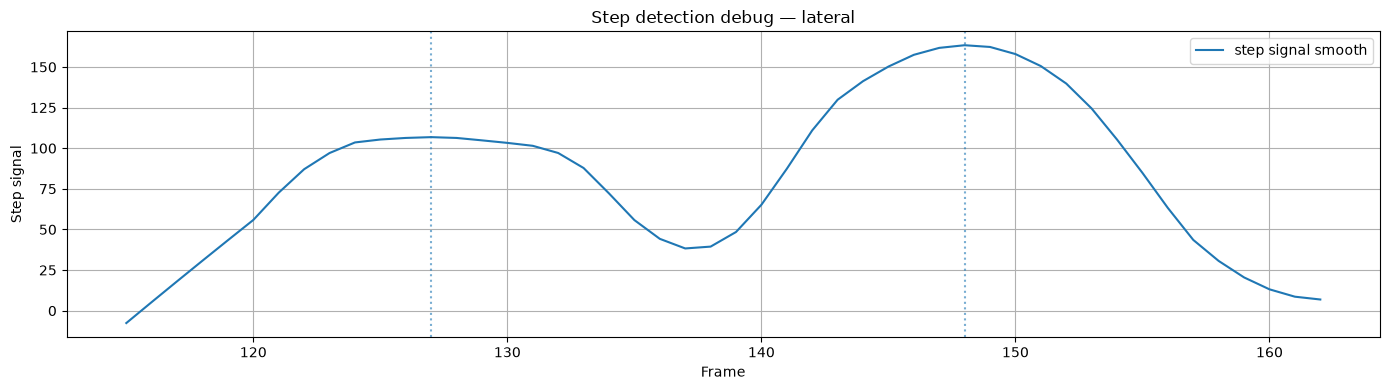

lateral
Detected steps: 2
Step frames: [127, 148]



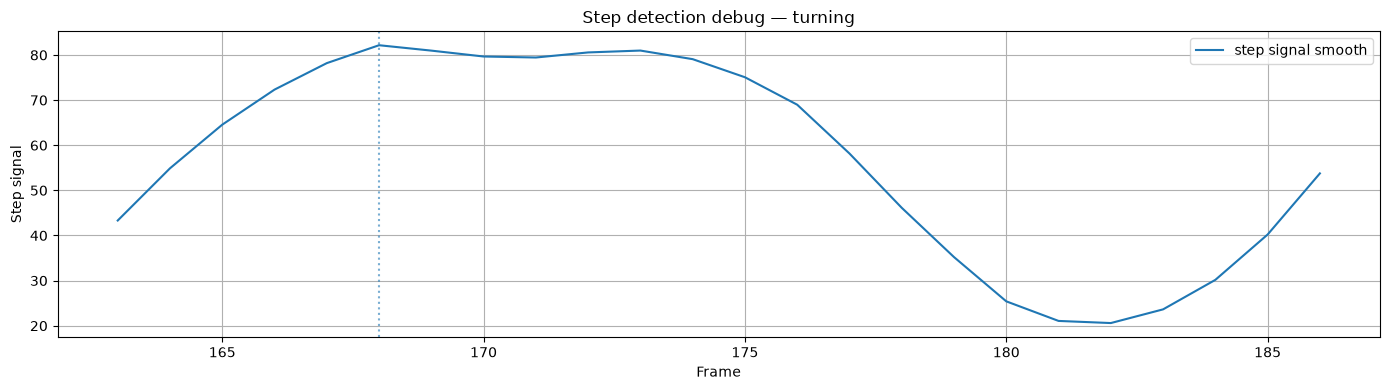

turning
Detected steps: 1
Step frames: [168]



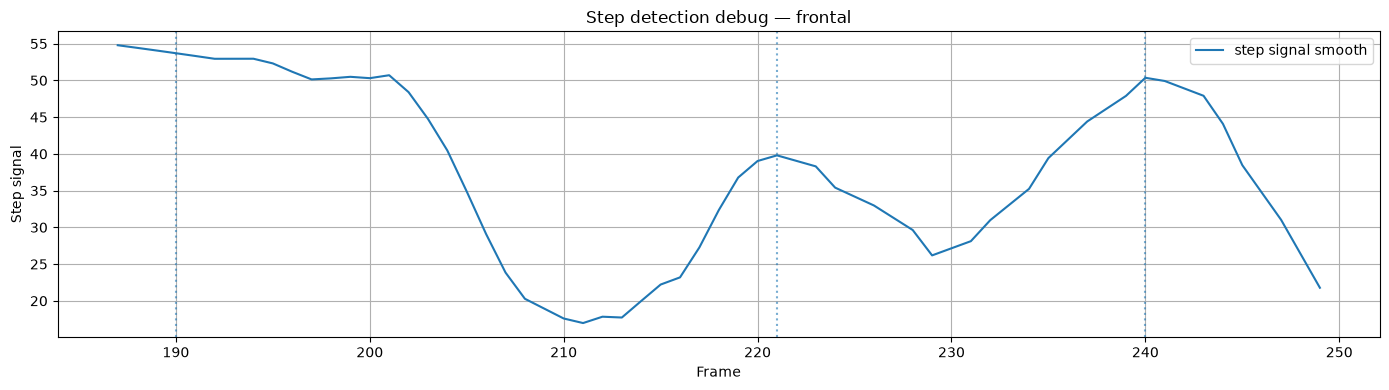

frontal
Detected steps: 3
Step frames: [190, 221, 240]



In [9]:
# ============================================================
# Cell 9 — Plot step detection signals
# ============================================================

for segment_name in ["lateral", "turning", "frontal"]:
    sub = signals_df[signals_df["segment"] == segment_name].copy()

    if len(sub) == 0:
        print(f"No signal rows for segment: {segment_name}")
        continue

    plt.figure(figsize=(14, 4))

    plt.plot(
        sub["Frame"],
        sub["step_signal_smooth"],
        label="step signal smooth",
    )

    step_rows = sub[sub["is_step_event"]]

    for frame in step_rows["Frame"]:
        plt.axvline(frame, linestyle=":", alpha=0.6)

    plt.title(f"Step detection debug — {segment_name}")
    plt.xlabel("Frame")
    plt.ylabel("Step signal")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(segment_name)
    print("Detected steps:", len(step_rows))
    print("Step frames:", step_rows["Frame"].astype(int).tolist())
    print()

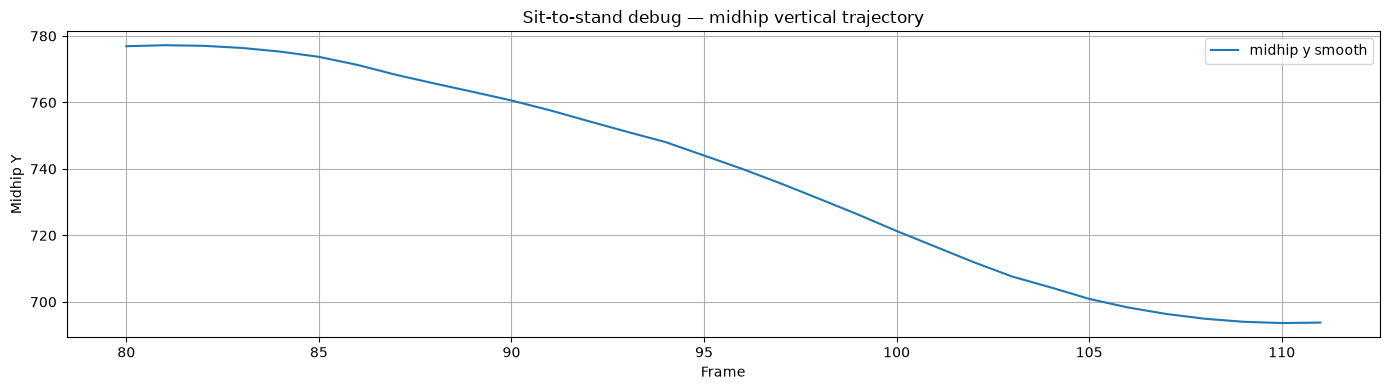

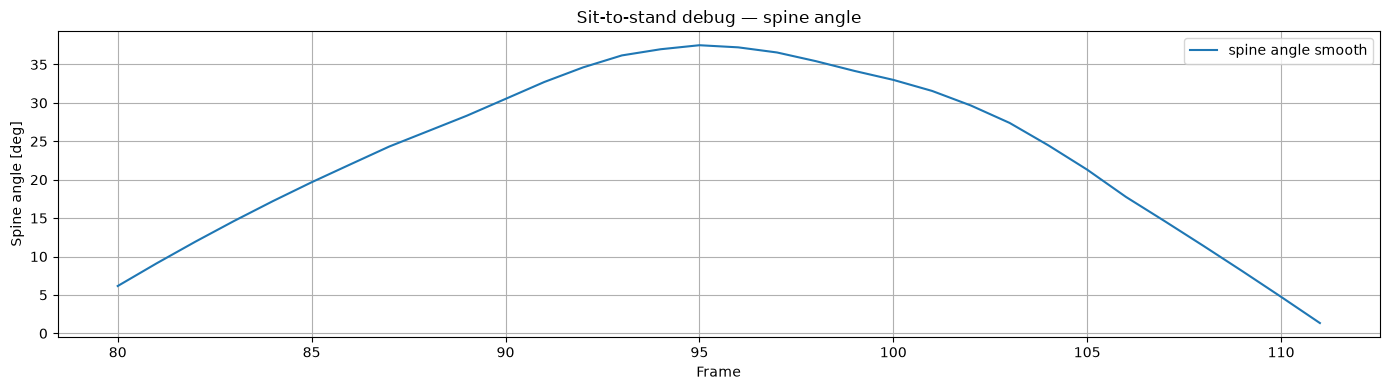

,segment,A11_sit_to_stand_time_sec,P26_spine_angle_in_stand_up_max_deg,P27_spine_angle_in_stand_up_mean_deg,P28_spine_angle_in_sitting_mean_deg,A12_spine_angle_standup_sd_deg,A13_spine_angle_standup_rom_deg,A14_spine_angle_velocity_max_deg_per_sec,A15_midhip_y_displacement_norm,A16_midhip_vertical_speed_max_norm_per_sec
0,sit_to_stand,1.06697,37.509205,23.653297,-0.555192,10.859866,36.170048,106.405799,83.164513,148.457005


In [10]:
# ============================================================
# Cell 10 — Plot sit-to-stand feature signals
# ============================================================

sts_sub = signals_df[signals_df["segment"] == "sit_to_stand"].copy()

if len(sts_sub) == 0:
    print("No sit-to-stand signal rows found.")
else:
    plt.figure(figsize=(14, 4))
    plt.plot(
        sts_sub["Frame"],
        sts_sub["midhip_y_smooth"],
        label="midhip y smooth",
    )
    plt.title("Sit-to-stand debug — midhip vertical trajectory")
    plt.xlabel("Frame")
    plt.ylabel("Midhip Y")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 4))
    plt.plot(
        sts_sub["Frame"],
        sts_sub["spine_angle_standup_smooth_deg"],
        label="spine angle smooth",
    )
    plt.title("Sit-to-stand debug — spine angle")
    plt.xlabel("Frame")
    plt.ylabel("Spine angle [deg]")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    display(
        features_df[
            features_df["segment"] == "sit_to_stand"
        ][[
            col for col in [
                "segment",
                "A11_sit_to_stand_time_sec",
                "P26_spine_angle_in_stand_up_max_deg",
                "P27_spine_angle_in_stand_up_mean_deg",
                "P28_spine_angle_in_sitting_mean_deg",
                "A12_spine_angle_standup_sd_deg",
                "A13_spine_angle_standup_rom_deg",
                "A14_spine_angle_velocity_max_deg_per_sec",
                "A15_midhip_y_displacement_norm",
                "A16_midhip_vertical_speed_max_norm_per_sec",
            ]
            if col in features_df.columns
        ]]
    )

In [11]:
# ============================================================
# Cell 11 — Real-time feature viewer on video
# ============================================================

import cv2
import numpy as np
import ipywidgets as widgets
from IPython.display import display

SKELETON_EDGES = [
    ("left_shoulder", "right_shoulder"),
    ("left_shoulder", "left_hip"),
    ("right_shoulder", "right_hip"),
    ("left_hip", "right_hip"),

    ("left_hip", "left_knee"),
    ("left_knee", "left_ankle"),
    ("left_ankle", "left_heel"),
    ("left_heel", "left_foot_index"),

    ("right_hip", "right_knee"),
    ("right_knee", "right_ankle"),
    ("right_ankle", "right_heel"),
    ("right_heel", "right_foot_index"),
]


def format_value(value, digits=3):
    if value is None:
        return "NA"
    try:
        if pd.isna(value):
            return "NA"
    except TypeError:
        pass

    if isinstance(value, (int, np.integer)):
        return str(int(value))

    if isinstance(value, (float, np.floating)):
        return f"{float(value):.{digits}f}"

    return str(value)


def get_phase_for_frame(frame):
    row = phase_df[phase_df["Frame"] == frame]

    if len(row) == 0:
        return "outside"

    return row["phase"].iloc[0]


def get_signal_row_for_frame(frame, phase):
    if phase == "outside":
        return None

    rows = signals_df[
        (signals_df["Frame"] == frame)
        & (signals_df["segment"] == phase)
    ]

    if len(rows) == 0:
        rows = signals_df[signals_df["Frame"] == frame]

    if len(rows) == 0:
        return None

    return rows.iloc[0]


def get_constant_row_for_phase(phase):
    if phase == "outside":
        return None

    rows = features_df[features_df["segment"] == phase]

    if len(rows) == 0:
        return None

    return rows.iloc[0]


def draw_skeleton_cv2(image, row, visibility_threshold=0.5):
    h, w = image.shape[:2]
    points_xy = {}

    for key, point in POINTS.items():
        x_col = f"{point}_x"
        y_col = f"{point}_y"
        v_col = f"{point}_vis"

        if x_col not in row.index or y_col not in row.index or v_col not in row.index:
            continue

        x = row[x_col]
        y = row[y_col]
        v = row[v_col]

        if not np.isfinite(x) or not np.isfinite(y) or not np.isfinite(v):
            continue

        if v < visibility_threshold:
            continue

        # Convert normalized coordinates to pixels if needed.
        if 0 <= x <= 1 and 0 <= y <= 1:
            x = x * w
            y = y * h

        points_xy[key] = (int(x), int(y))

    for p1, p2 in SKELETON_EDGES:
        if p1 in points_xy and p2 in points_xy:
            cv2.line(image, points_xy[p1], points_xy[p2], (0, 255, 0), 2)

    for x, y in points_xy.values():
        cv2.circle(image, (x, y), 4, (255, 0, 0), -1)

    return image


def get_dynamic_lines(signal_row, phase):
    if signal_row is None:
        return ["No frame-level feature row"]

    lines = []

    if phase in ["lateral", "turning", "frontal"]:
        lines.extend([
            f"step_signal_smooth: {format_value(signal_row.get('step_signal_smooth'))}",
            f"is_step_event: {format_value(signal_row.get('is_step_event'))}",
            f"step_event_source: {format_value(signal_row.get('step_event_source'))}",
            f"ankle_x_distance: {format_value(signal_row.get('ankle_x_distance'))}",
            f"knee_x_distance: {format_value(signal_row.get('knee_x_distance'))}",
            f"spine_angle_deg: {format_value(signal_row.get('spine_angle_deg'))}",
            f"left_knee_angle_deg: {format_value(signal_row.get('left_knee_angle_deg'))}",
            f"right_knee_angle_deg: {format_value(signal_row.get('right_knee_angle_deg'))}",
        ])

    elif phase == "sit_to_stand":
        lines.extend([
            f"midhip_y_smooth: {format_value(signal_row.get('midhip_y_smooth'))}",
            f"midhip_vertical_speed: {format_value(signal_row.get('midhip_upward_speed_norm_per_sec'))}",
            f"spine_angle_standup: {format_value(signal_row.get('spine_angle_standup_smooth_deg'))}",
            f"spine_angle_velocity: {format_value(signal_row.get('spine_angle_velocity_deg_per_sec'))}",
        ])

    else:
        lines.append("Outside extracted segments")

    return lines


def get_constant_lines(constant_row, phase):
    if constant_row is None:
        return []

    if phase in ["lateral", "turning", "frontal"]:
        return [
            f"segment_time: {format_value(constant_row.get('gait_time_sec'))} s",
            f"steps: {format_value(constant_row.get('A02_number_of_steps'))}",
            f"cadence: {format_value(constant_row.get('A05_cadence_steps_per_min'))} steps/min",
            f"step_signal_used: {format_value(constant_row.get('A07_step_signal_used'))}",
        ]

    if phase == "sit_to_stand":
        return [
            f"STS time: {format_value(constant_row.get('A11_sit_to_stand_time_sec'))} s",
            f"midhip displacement: {format_value(constant_row.get('A15_midhip_y_displacement_norm'))}",
            f"max midhip speed: {format_value(constant_row.get('A16_midhip_vertical_speed_max_norm_per_sec'))}",
        ]

    return []


cap = cv2.VideoCapture(str(VIDEO_PATH))

if not cap.isOpened():
    raise ValueError(f"Could not open video: {VIDEO_PATH}")


image_widget = widgets.Image(
    format="jpeg",
    width=850,
)

frame_label = widgets.HTML()

row_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(df) - 1,
    step=1,
    description="CSV row",
    continuous_update=False,
)

play = widgets.Play(
    value=0,
    min=0,
    max=len(df) - 1,
    step=1,
    interval=120,
    description="Play",
    disabled=False,
)

widgets.jslink((play, "value"), (row_slider, "value"))

prev_button = widgets.Button(description="Previous")
next_button = widgets.Button(description="Next")


def make_frame(row_index):
    row_index = int(row_index)

    skeleton_row = df.iloc[row_index]
    frame_number = int(skeleton_row["Frame"])
    phase = get_phase_for_frame(frame_number)

    signal_row = get_signal_row_for_frame(frame_number, phase)
    constant_row = get_constant_row_for_phase(phase)

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ok, frame_bgr = cap.read()

    if not ok:
        return None, f"Could not read video frame {frame_number}"

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    # Resize for smoother display
    display_width = 850
    h, w = frame_rgb.shape[:2]
    scale = display_width / w
    display_height = int(h * scale)

    frame_rgb = cv2.resize(
        frame_rgb,
        (display_width, display_height),
        interpolation=cv2.INTER_AREA,
    )

    # Scale skeleton coordinates when they are pixel coordinates.
    row_scaled = skeleton_row.copy()

    for point in POINTS.values():
        x_col = f"{point}_x"
        y_col = f"{point}_y"

        if x_col in row_scaled.index and y_col in row_scaled.index:
            x = row_scaled[x_col]
            y = row_scaled[y_col]

            if np.isfinite(x) and np.isfinite(y):
                if not (0 <= x <= 1 and 0 <= y <= 1):
                    row_scaled[x_col] = x * scale
                    row_scaled[y_col] = y * scale

    frame_rgb = draw_skeleton_cv2(frame_rgb, row_scaled)

    dynamic_lines = get_dynamic_lines(signal_row, phase)
    constant_lines = get_constant_lines(constant_row, phase)

    overlay_lines = [
        f"Frame: {frame_number}",
        f"Phase: {phase}",
    ] + dynamic_lines[:6]

    # Draw text overlay.
    y = 28
    for line in overlay_lines:
        cv2.putText(
            frame_rgb,
            line,
            (20, y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.60,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )
        y += 25

    frame_bgr_out = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
    ok, encoded = cv2.imencode(".jpg", frame_bgr_out)

    if not ok:
        return None, "Could not encode frame."

    html_lines = [
        f"<b>CSV row:</b> {row_index}",
        f"<b>Video frame:</b> {frame_number}",
        f"<b>Phase:</b> {phase}",
        "<br><b>Frame-level changing values:</b>",
        *dynamic_lines,
    ]

    if len(constant_lines) > 0:
        html_lines.extend([
            "<br><b>Constant segment values:</b>",
            *constant_lines,
        ])

    html = "<br>".join(html_lines)

    return encoded.tobytes(), html


def update_view(change=None):
    image_bytes, html = make_frame(row_slider.value)

    frame_label.value = html

    if image_bytes is not None:
        image_widget.value = image_bytes


def go_previous(_):
    row_slider.value = max(row_slider.min, row_slider.value - 1)


def go_next(_):
    row_slider.value = min(row_slider.max, row_slider.value + 1)


prev_button.on_click(go_previous)
next_button.on_click(go_next)
row_slider.observe(update_view, names="value")

controls = widgets.VBox([
    widgets.HBox([play, prev_button, next_button]),
    row_slider,
    frame_label,
])

display(controls)
display(image_widget)

update_view()

Image(value=b'', format='jpeg', width='850')

## Notes for debugging

- `features_df` contains segment-level scalar features. These values are constant within a segment.
- `signals_df` contains frame-level values. These are the values used by the real-time viewer.
- The skeleton correction happens before segmentation and feature extraction, because all later steps should use the corrected landmark trajectories.